<a href="https://colab.research.google.com/github/Shivam250124/Machine_Learning-/blob/main/assignment1_Ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Problem Statement

You are a data scientist / AI engineer at a medical research firm. You have been provided with a dataset named **`"cancer_data.csv"`**, which includes medical and lifestyle information for 1500 patients. The dataset is designed to predict the presence of cancer based on various features. The dataset comprises the following columns:

- `age:` Integer values representing the patient's age, ranging from 20 to 80.
- `gender:` Binary values representing gender, where 0 indicates Male and 1 indicates Female.
- `bmi:` Continuous values representing Body Mass Index, ranging from 15 to 40.
- `smoking:` Binary values indicating smoking status, where 0 means No and 1 means Yes.
- `genetic_risk:` Categorical values representing genetic risk levels for cancer, with 0 indicating Low, 1 indicating Medium, and 2 indicating High.
- `physical_activity:` Continuous values representing the number of hours per week spent on physical activities, ranging from 0 to 10.
- `alcohol_intake:` Continuous values representing the number of alcohol units consumed per week, ranging from 0 to 5.
- `cancer_history:` Binary values indicating whether the patient has a personal history of cancer, where 0 means No and 1 means Yes.
- `diagnosis:` Binary values indicating the cancer diagnosis status, where 0 indicates No Cancer and 1 indicates Cancer.

  
Your task is to use this dataset to build and compare the performance of Decision Tree and Random Forest models to predict the presence of cancer. Additionally, explore various parameters of the RandomForestClassifier to enhance model performance.

**Dataset credits:** Rabie El Kharoua (https://www.kaggle.com/datasets/rabieelkharoua/cancer-prediction-dataset)

**Import Necessary Libraries**

In [2]:
#import necessary libraries
import pandas as pd


### Task 1: Data Preparation and Exploration

1. Import the data from the `"cancer_data.csv"` file and store it in a variable df.
2. Display the number of rows and columns in the dataset.
3. Display the first few rows of the dataset to get an overview.
4. Check for any missing values in the dataset.

In [3]:
# Step 1: Import the data from the "cancer_data.csv" file and store it in a variable 'df'

df=pd.read_csv("cancer_data.csv")
# Step 2: Display the number of rows and columns in the dataset

print(df.shape)
# Step 3: Display the first few rows of the dataset to get an overview
df.head()

(1500, 9)


,age,gender,bmi,smoking,genetic_risk,physical_activity,alcohol_intake,cancer_history,diagnosis
0,58,1,16.085313,0,1,8.146251,4.148219,1,1
1,71,0,30.828784,0,1,9.361630,3.519683,0,0
2,48,1,38.785084,0,2,5.135179,4.728368,0,1
3,34,0,30.040295,0,0,9.502792,2.044636,0,0
4,62,1,35.479721,0,0,5.356890,3.309849,0,1


In [4]:
# Step 4: Check for any missing values in the dataset
df.isnull().sum()

,0
age,0
gender,0
bmi,0
smoking,0
genetic_risk,0
physical_activity,0
alcohol_intake,0
cancer_history,0
diagnosis,0


### Task 2: Model Training Using Decision Tree Classifier

1. Select the features `(age, gender, bmi, smoking, genetic_risk, physical_activity, alcohol_intake, cancer_history)` and the target variable `(diagnosis)` for modeling.
2. Split the data into training and test sets with a test size of 25%.
3. Initialize and train a Decision Tree Classifier model using the training data.
4. Make predictions on the test set using the trained model.
5. Evaluate the model using a classification report and print the report.

In [5]:
# Step 1: Select the features and target variable for modeling
X=df.drop("diagnosis",axis=1)
y=df["diagnosis"]

# Step 2: Split the data into training and test sets with a test size of 25%
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [6]:
# Step 3: Initialize and train a Decision Tree Classifier model using the training data
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)

# Step 4: Make predictions on the test set using the trained model
y_pred=dt.predict(X_test)

# Step 5: Evaluate the model using a classification report and print the report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       233
           1       0.84      0.83      0.83       142

    accuracy                           0.87       375
   macro avg       0.87      0.87      0.87       375
weighted avg       0.87      0.87      0.87       375



### Task 3: Model Training Using Random Forest Classifier

1. Initialize and train a Random Forest Classifier model with 25 estimators using the training data.
2. Make predictions on the test set using the trained model.
3. Evaluate the model using a classification report and print the report.

In [7]:
# Step 1: Initialize and train a Random Forest Classifier model with 25 estimators using the training data

from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=25)
rf.fit(X_train,y_train)
# Step 2: Make predictions on the test set using the trained model

y_pred=rf.predict(X_test)
# Step 3: Evaluate the model using a classification report and print the report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.93      0.93       233
           1       0.88      0.87      0.88       142

    accuracy                           0.91       375
   macro avg       0.90      0.90      0.90       375
weighted avg       0.91      0.91      0.91       375



### Task 4: Exploring Various Parameters in Random Forest Classifier

1. Train a Random Forest model with the following parameters:
   - n_estimators = 50
   - max_features = "log2"
   - criterion = "entropy"
   - bootstrap = False
   - max_depth = 15
   - min_samples_split = 5
   - min_samples_leaf = 3

Learn about these parameters here: [scikit-learn RandomForestClassifier Parameters](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)


--------------------------------------------------------------------------------------------------------------------------------------------------------
2. Evaluate the model using a classification report and print the report.

In [9]:
# Step 1: Train a Random Forest model with specified parameters
rf1=RandomForestClassifier(n_estimators=50,max_features="log2",criterion="entropy",bootstrap=False,max_depth=15,min_samples_split=5,min_samples_leaf=3)
rf1.fit(X_train,y_train)
# Step 2: Make predictions on the test set using the trained model
y_pred=rf1.predict(X_test)

# Step 3: Evaluate the model using a classification report and print the report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       233
           1       0.91      0.87      0.89       142

    accuracy                           0.92       375
   macro avg       0.92      0.91      0.91       375
weighted avg       0.92      0.92      0.92       375



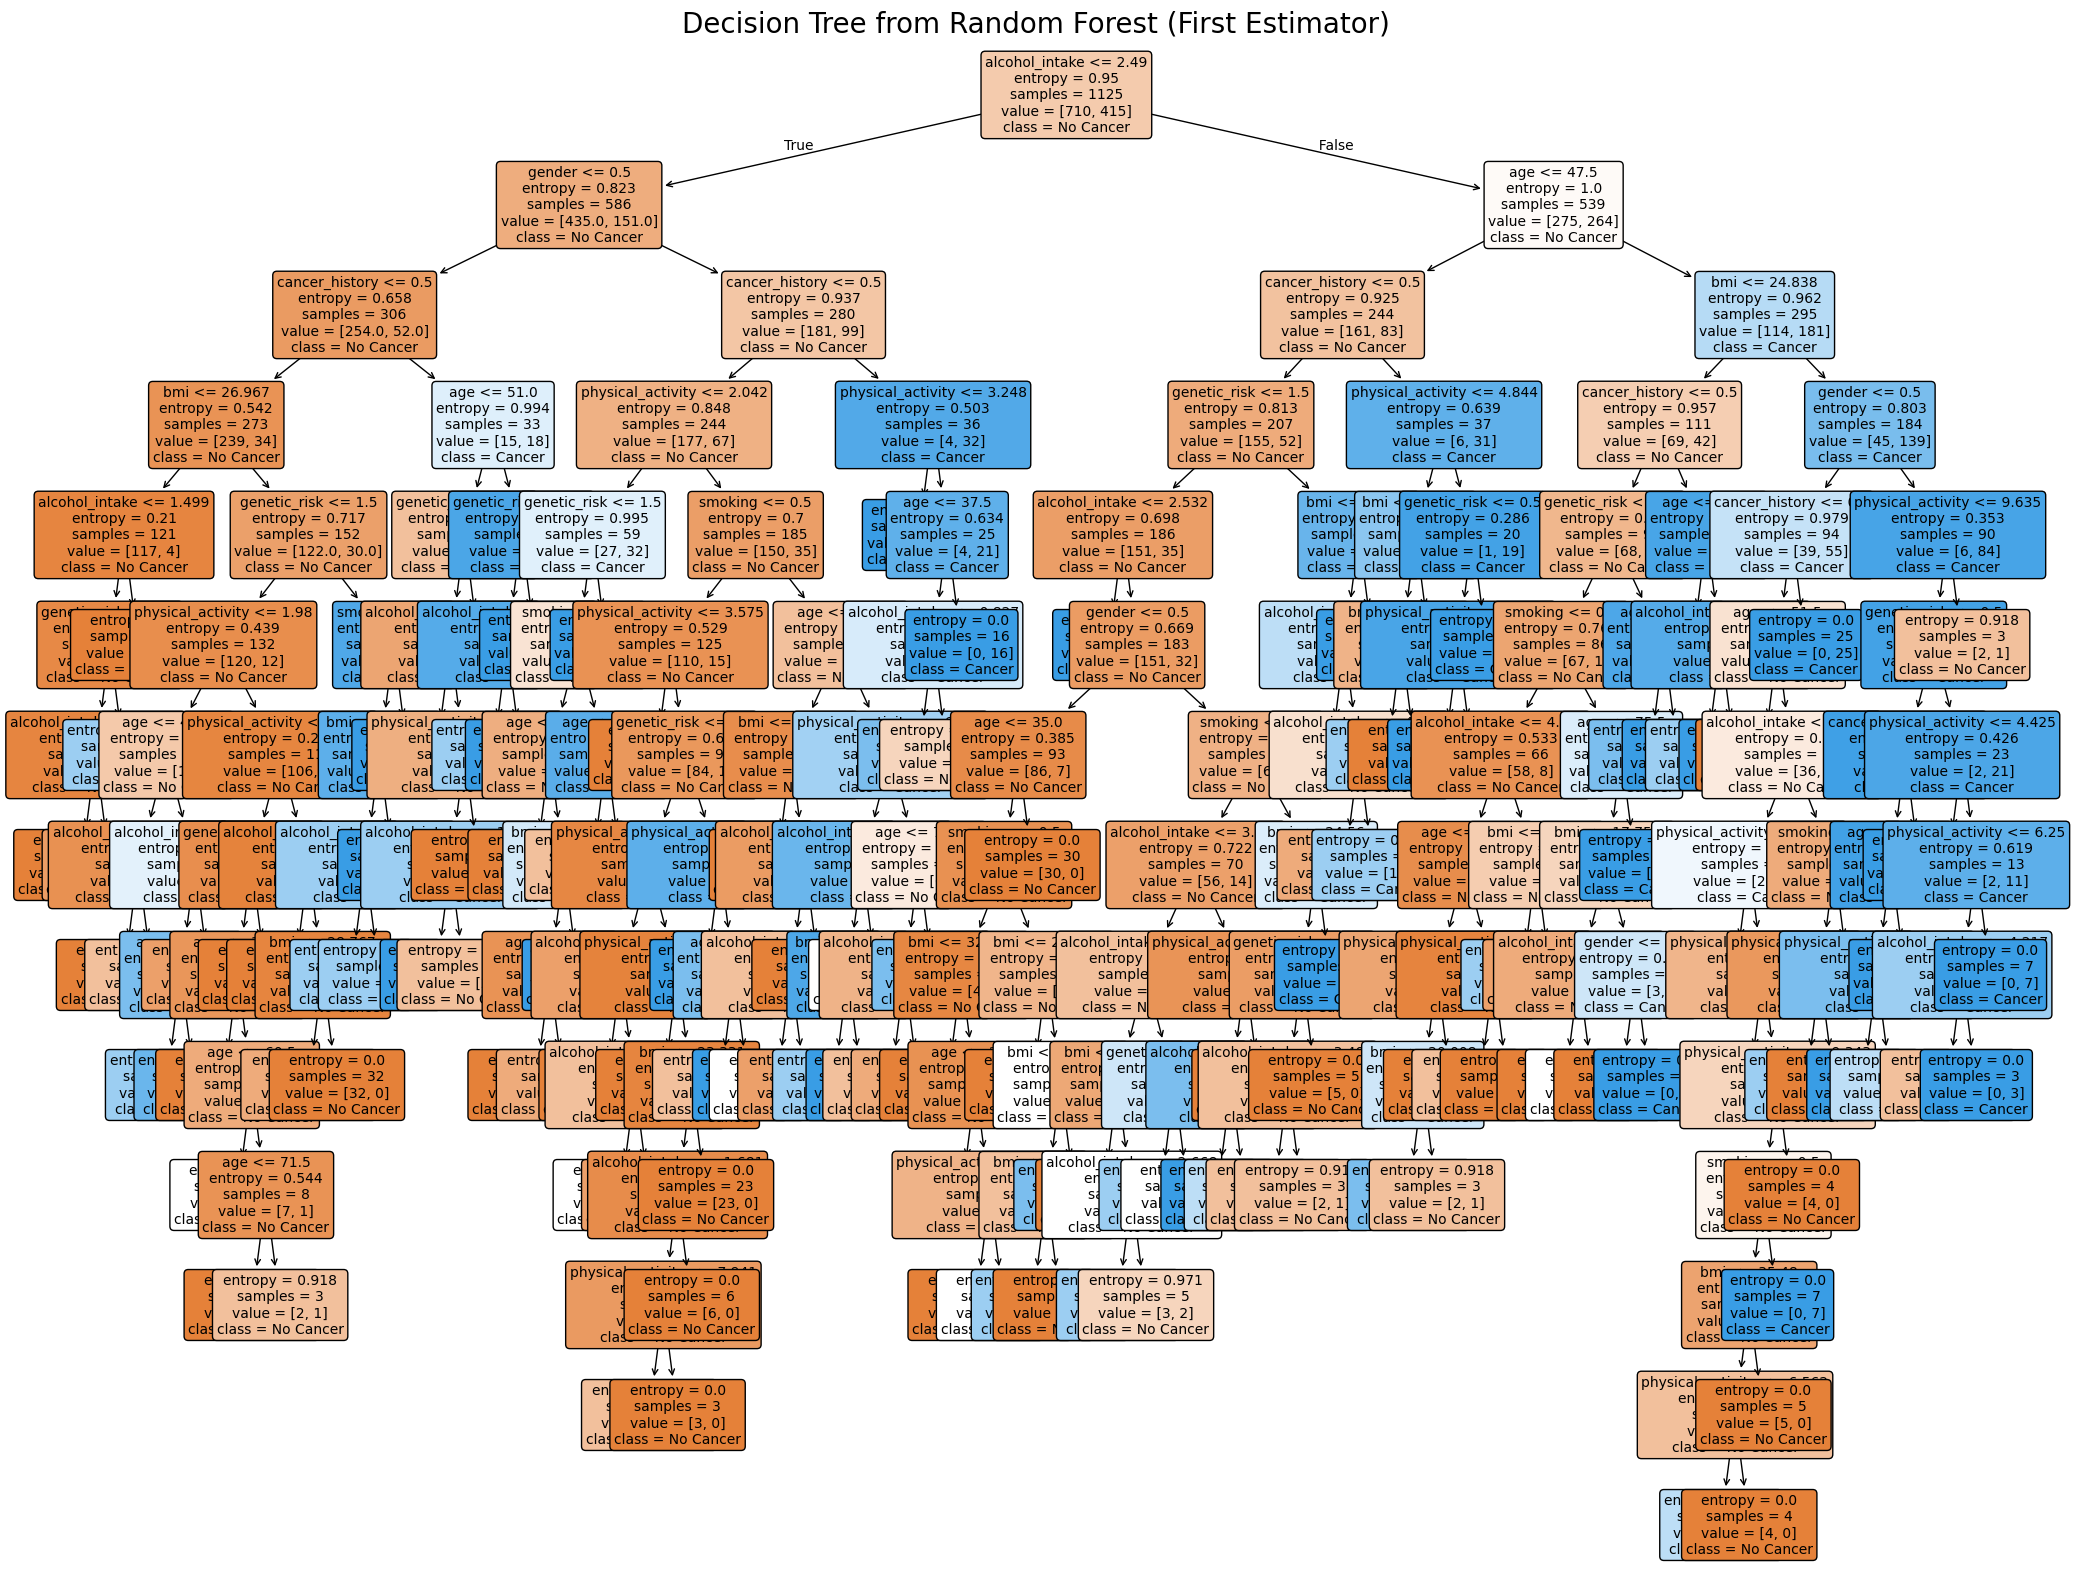

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Select one tree from the Random Forest (e.g., the first one)
one_tree = rf1.estimators_[0]

# Get feature names from the training data
feature_names = X_train.columns.tolist()

# Get class names for the target variable
# Assuming y is binary (0: No Cancer, 1: Cancer)
class_names = ['No Cancer', 'Cancer']

plt.figure(figsize=(25, 20))
plot_tree(one_tree,
          feature_names=feature_names,
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision Tree from Random Forest (First Estimator)", fontsize=20)
plt.show()

### Clarification on `min_samples_leaf`

YouYou observed a leaf node with 2 samples, despite `min_samples_leaf` being set to 3. This is how `min_samples_leaf` works:

`min_samples_leaf` specifies the **minimum number of samples required to be in a *leaf node*** for a *split to be considered valid*. More precisely, it means that a split will only be attempted if both the resulting left child and the resulting right child would each have at least `min_samples_leaf` samples.

If a node (before splitting) has, for example, only 2 samples, it's impossible to split it into two children where each child has at least 3 samples (since `min_samples_leaf = 3`). In such a scenario, the node simply cannot be split further according to the rule, and it becomes a leaf node itself, even if it contains fewer samples than `min_samples_leaf`.

Therefore, a leaf node can contain fewer samples than the `min_samples_leaf` value if it's a node that *could not be split further* while satisfying the `min_samples_leaf` condition for its potential children.